# 03 · Event study

H1, H2, H3 and H5 on the primary specification.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from deadcat import data as D, plotting as P
from deadcat.config import load_config
P.use_style(); pd.set_option("display.width", 180)
cfg = load_config(ROOT / "configs" / "default.yaml")
T = ROOT / "results" / "tables"; M = ROOT / "results" / "metrics"
print("config fingerprint:", cfg.fingerprint)

config fingerprint: a9ca33aed3d9


## H1 — is there a bounce at all?

In [2]:
hz = pd.read_csv(T / "car_by_horizon.csv")
display(hz.round(5))
print("Negative at every horizon; CI excludes zero at every horizon.")

,horizon,mean,lo,hi,n,p_two_sided
0,1,-0.00101,-0.00141,-0.00064,14676,0.0
1,5,-0.00268,-0.00342,-0.00192,14675,0.0
2,10,-0.00187,-0.00283,-0.00089,14668,0.0
3,20,-0.00265,-0.00403,-0.00124,14647,0.0
4,60,-0.00425,-0.00658,-0.00200,14539,0.0


Negative at every horizon; CI excludes zero at every horizon.


In [3]:
h1 = pd.read_csv(T / "h1_mean_car_by_group.csv")
display(h1.round(5))

,group,mean_car20,median_car20,ci_lo,ci_hi,p_value,n,recovery_rate,regained_precrash_rate,q_value,reject_fdr
0,all_events,-0.00265,-0.00431,-0.00403,-0.00124,0.000,14647,0.47143,0.38943,0.0000,True
1,broad_market,-0.00351,-0.00387,-0.00612,-0.00099,0.005,4948,0.47332,0.48201,0.0100,True
2,sector,-0.00241,-0.00405,-0.00680,0.00247,0.305,1444,0.47022,0.43283,0.3450,False
3,idiosyncratic,-0.00226,-0.00446,-0.00398,-0.00055,0.007,8166,0.47098,0.32586,0.0112,True
4,avol_q4_highest,-0.00138,-0.00497,-0.00428,0.00166,0.345,3653,0.46619,0.21571,0.3450,False
5,avol_q1_lowest,-0.00565,-0.00488,-0.00812,-0.00317,0.000,3657,0.46377,0.47717,0.0000,True
6,high_vix,-0.00182,-0.00453,-0.00529,0.00192,0.309,3699,0.47310,0.47770,0.3450,False
7,low_vix,-0.00294,-0.00423,-0.00427,-0.00155,0.000,10948,0.47086,0.35961,0.0000,True


## H2 / H3 / H5 — conditional contrasts

`q_value` is the Benjamini–Hochberg adjusted p across the five pre-registered contrasts.

In [4]:
con = pd.read_csv(T / "group_contrasts.csv")
display(con[["hypothesis", "group_a", "group_b", "diff", "ci_lo", "ci_hi",
             "p_value", "q_value", "reject_fdr"]].round(5))
print("Nothing survives FDR correction.")

,hypothesis,group_a,group_b,diff,ci_lo,ci_hi,p_value,q_value,reject_fdr
0,H2,broad_market,idiosyncratic,-0.00124,-0.00439,0.00165,0.429,0.845,False
1,H2,sector,idiosyncratic,-0.00015,-0.00477,0.00494,0.948,0.948,False
2,H2,broad_market,sector,-0.00110,-0.00665,0.00432,0.676,0.845,False
3,H3,avol_q4_highest,avol_q1_lowest,0.00427,0.00051,0.00806,0.028,0.140,False
4,H5,high_vix,low_vix,0.00112,-0.00260,0.00518,0.572,0.845,False


Nothing survives FDR correction.


## Event-time paths

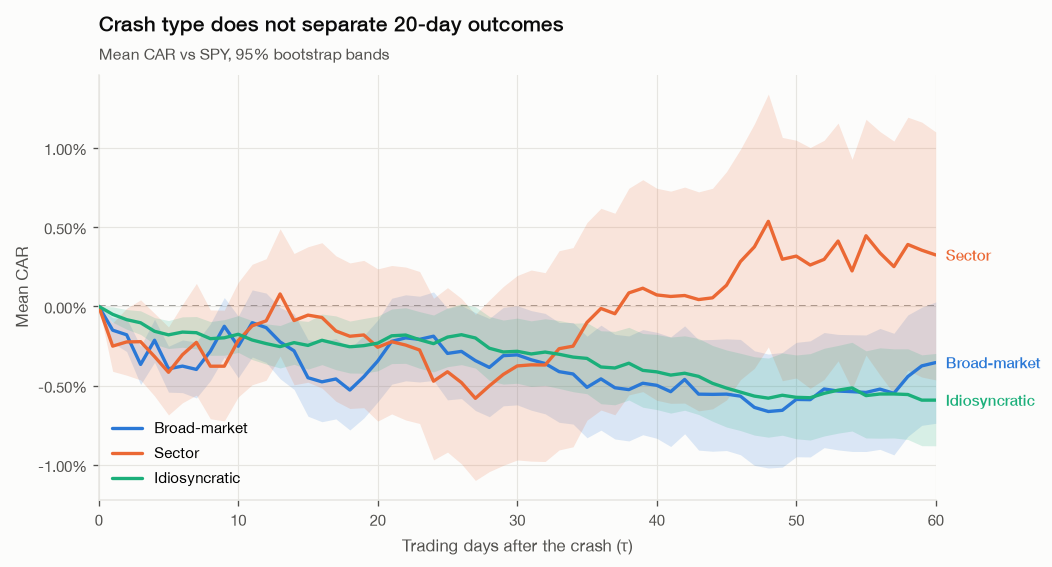

In [5]:
paths = pd.read_csv(T / "event_study_paths.csv")
fig, ax = plt.subplots(figsize=(9, 4.6))
P.zero_line(ax)
for t in ("broad_market", "sector", "idiosyncratic"):
    g = paths[paths.group == t]
    P.band(ax, g.tau.values, g.mean_car.values, g.lo.values, g.hi.values,
           P.CRASH_TYPE_COLORS[t], P.CRASH_TYPE_LABELS[t])
P.pct_axis(ax, "y", 2); ax.set_xlim(0, 60); ax.set_xmargin(0.16)
ax.set_xlabel("Trading days after the crash (τ)"); ax.set_ylabel("Mean CAR")
ax.legend(loc="lower left")
P.finish(fig, ax, "Crash type does not separate 20-day outcomes",
         "Mean CAR vs SPY, 95% bootstrap bands")
plt.show()

## Where crash type *does* matter

Not in abnormal return, but in how deep the hole is.

In [6]:
display(h1.set_index("group")[["mean_car20", "recovery_rate", "regained_precrash_rate"]]
        .loc[["broad_market", "sector", "idiosyncratic"]].round(4))
print("Broad-market crashes regain the pre-crash price far more often (48.2% vs 32.6%)")
print("while their abnormal return is statistically identical.")

,mean_car20,recovery_rate,regained_precrash_rate
group,,,
broad_market,-0.0035,0.4733,0.4820
sector,-0.0024,0.4702,0.4328
idiosyncratic,-0.0023,0.4710,0.3259


Broad-market crashes regain the pre-crash price far more often (48.2% vs 32.6%)
while their abnormal return is statistically identical.
